# 01 - Exploratory Data Analysis (EDA)

This notebook performs an extensive Exploratory Data Analysis (EDA) on the raw 
insurance claims data. The goal is to understand the data's structure, identify patterns, 
detect anomalies, and prepare it for subsequent modeling and hypothesis testing.

We will cover:

1.Loading the raw data.

2.Initial data overview (shape, head, tail, info, describe).

3.Missing value analysis.

4.Unique value counts for categorical features.

5.Distribution analysis of key numerical features and target variables.

6.Correlation analysis.

The data preparation steps (loading, cleaning, feature engineering, missing data 
handling) will primarily utilize functions from src/data_preparation.py and 
src/feature_engineering.py for consistency with the overall pipeline.

In [12]:
# --- Setup and Imports ---
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamically determine the project root more robustly.
# This logic will find the directory that contains 'src' regardless of
# where the Jupyter kernel was launched from, assuming a standard project structure.

# Start from the current working directory (where the Jupyter kernel is running)
current_path = os.getcwd()
actual_project_root = None

# Walk up the directory tree until 'src' directory is found
while True:
    if os.path.exists(os.path.join(current_path, 'src')):
        actual_project_root = current_path
        break
    parent_path = os.path.dirname(current_path)
    if parent_path == current_path: # Reached file system root
        break
    current_path = parent_path

if actual_project_root is None:
    raise RuntimeError("Could not find the project root containing the 'src' directory. "
                       "Please ensure 'src' is directly within your project root, "
                       "and you are running Jupyter from within the project structure.")

# Ensure the actual project root is at the very beginning of sys.path
# This ensures that 'src' can be imported correctly.
if actual_project_root in sys.path:
    sys.path.remove(actual_project_root) # Remove if already present to ensure it's at index 0
sys.path.insert(0, actual_project_root)

print(f"Detected project root: '{actual_project_root}'")
print(f"Ensured project root is at the beginning of sys.path.")
print(f"Current sys.path (first 3 entries): {sys.path[:3]}") # Print to confirm

# Import modules from src
from src.data_preparation import load_raw_data, _convert_comma_to_dot_and_numeric, handle_missing_data
from src.feature_engineering import engineer_features # Import engineer_features separately
from src.config import (
    RAW_DATA_PATH, TOTAL_CLAIMS_COL, TOTAL_PREMIUM_COL, HAS_CLAIM_COL, MARGIN_COL,
    NUMERICAL_FEATURES_CLASSIFICATION, CATEGORICAL_FEATURES_CLASSIFICATION, DATE_FEATURES_CLASSIFICATION,
    NUMERICAL_FEATURES_REGRESSION,
    TRANSACTION_MONTH_COL, # <--- ADDED THIS IMPORT
    POLICY_ID_COL, DRIVER_GENDER_COL, PROVINCE_COL, POSTAL_CODE_COL
)

# Configure plotting styles
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


Detected project root: 'C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis'
Ensured project root is at the beginning of sys.path.
Current sys.path (first 3 entries): ['C:\\Users\\benke\\Desktop\\DataScience\\10Academy\\Kefiya_AI_Mastery\\Week3\\KAIM_W3_Insurance_risk_analysis\\KAIM_W03_AlphaCare_Insurance_Risk_Analysis', 'C:\\Users\\benke\\Desktop\\DataScience\\10Academy\\Kefiya_AI_Mastery\\Week3\\KAIM_W3_Insurance_risk_analysis', 'C:\\Users\\benke\\Desktop\\DataScience\\10Academy\\Kefiya_AI_Mastery\\Week3\\KAIM_W3_Insurance_risk_analysis\\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\\notebooks']


# 1. Load Raw Data

In [13]:
df_raw = load_raw_data(RAW_DATA_PATH)
if df_raw.empty:
    print("Failed to load raw data. Please check RAW_DATA_PATH in src/config.py and data file existence.")
else:
    print("Raw data loaded successfully. Displaying first 5 rows:")
    display(df_raw.head())

C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\src\data_preparation.py:28: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter='|')


Raw data loaded successfully from C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\data\raw\MachineLearningRating_v3.txt. Shape: (1000098, 52)
Raw data loaded successfully. Displaying first 5 rows:


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


# 2. Initial Data Cleaning & Feature Derivation for EDA

In [14]:
# Create a copy for EDA-specific processing to avoid modifying the original loaded df_raw
df_eda = df_raw.copy()
df_eda.columns = df_eda.columns.str.strip()

# Define all columns that are or should be numeric for initial conversion (as per config and data observations)
# This is a superset to catch all numerical columns potentially existing or engineered
potential_numeric_cols = list(set(
    NUMERICAL_FEATURES_CLASSIFICATION + 
    NUMERICAL_FEATURES_REGRESSION + # Include regression features too for comprehensive EDA
    [TOTAL_CLAIMS_COL, TOTAL_PREMIUM_COL, 'CustomValueEstimate', 'CapitalOutstanding',
     'SumInsured', 'CalculatedPremiumPerTerm', MARGIN_COL, HAS_CLAIM_COL,
     'PremiumPerSumInsured', 'VehicleAge_at_Transaction',
     f'{TRANSACTION_MONTH_COL}_Year', f'{TRANSACTION_MONTH_COL}_Month',
     'VehicleIntroDate_Year', 'VehicleIntroDate_Month'
    ],
))
# Filter to only include columns actually present in the DataFrame for conversion
potential_numeric_cols_in_df = [col for col in potential_numeric_cols if col in df_eda.columns]

# Perform comma-to-dot and numeric conversion for all relevant numerical columns
df_eda = _convert_comma_to_dot_and_numeric(df_eda, potential_numeric_cols_in_df)

# Calculate HasClaim and Margin (needed for EDA on targets). These are now handled in data_preparation.py
# for a fuller pipeline, but can be explicitly shown here for clarity in EDA.
if TOTAL_CLAIMS_COL in df_eda.columns:
    df_eda[HAS_CLAIM_COL] = (pd.to_numeric(df_eda[TOTAL_CLAIMS_COL], errors='coerce').fillna(0) > 0).astype(int)
else:
    df_eda[HAS_CLAIM_COL] = 0

if TOTAL_PREMIUM_COL in df_eda.columns and TOTAL_CLAIMS_COL in df_eda.columns:
    df_eda[MARGIN_COL] = pd.to_numeric(df_eda[TOTAL_PREMIUM_COL], errors='coerce').fillna(0) - pd.to_numeric(df_eda[TOTAL_CLAIMS_COL], errors='coerce').fillna(0)
else:
    df_eda[MARGIN_COL] = 0.0

# Ensure non-negativity for relevant financial/count columns after derivation
for col in potential_numeric_cols_in_df + [MARGIN_COL]:
    if col in df_eda.columns and pd.api.types.is_numeric_dtype(df_eda[col]):
        df_eda[col] = df_eda[col].clip(lower=0)

# Apply feature engineering for derived date features and others
df_eda_engineered = engineer_features(df_eda, DATE_FEATURES_CLASSIFICATION)

# Finally, handle missing data using the robust function from data_preparation on all current columns
# Identify all numerical and categorical columns present after engineering for comprehensive imputation
all_current_numeric_cols = [col for col in df_eda_engineered.select_dtypes(include=np.number).columns if col not in [HAS_CLAIM_COL]]
all_current_categorical_cols = [col for col in df_eda_engineered.select_dtypes(include='object').columns]

df_final_eda = handle_missing_data(df_eda_engineered, 
                                   all_current_numeric_cols, 
                                   all_current_categorical_cols)

print("Data cleaned and features derived for EDA. Displaying info and first rows:")
df_final_eda.info()
display(df_final_eda.head())

C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\src\feature_engineering.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_engineered[col] = pd.to_datetime(df_engineered[col], errors='coerce')


Data cleaned and features derived for EDA. Displaying info and first rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 60 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   UnderwrittenCoverID        1000098 non-null  int64         
 1   PolicyID                   1000098 non-null  int64         
 2   TransactionMonth           1000098 non-null  datetime64[ns]
 3   IsVATRegistered            1000098 non-null  bool          
 4   Citizenship                1000098 non-null  object        
 5   LegalType                  1000098 non-null  object        
 6   Title                      1000098 non-null  object        
 7   Language                   1000098 non-null  object        
 8   Bank                       1000098 non-null  object        
 9   AccountType                1000098 non-null  object        
 10  MaritalStatus              

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,TotalPremium,TotalClaims,HasClaim,Margin,PremiumPerSumInsured,TransactionMonth_Year,TransactionMonth_Month,VehicleIntroDate_Year,VehicleIntroDate_Month,VehicleAge_at_Transaction
0,145249,12827,2015-03-01,True,ZA,Close Corporation,Mr,English,First National Bank,Current account,...,21.929825,0.0,0,21.929825,2192.982456,2015,3,2002,6,13
1,145249,12827,2015-05-01,True,ZA,Close Corporation,Mr,English,First National Bank,Current account,...,21.929825,0.0,0,21.929825,2192.982456,2015,5,2002,6,13
2,145249,12827,2015-07-01,True,ZA,Close Corporation,Mr,English,First National Bank,Current account,...,0.000000,0.0,0,0.000000,0.000000,2015,7,2002,6,13
3,145255,12827,2015-05-01,True,ZA,Close Corporation,Mr,English,First National Bank,Current account,...,512.848070,0.0,0,512.848070,0.004299,2015,5,2002,6,13
4,145255,12827,2015-07-01,True,ZA,Close Corporation,Mr,English,First National Bank,Current account,...,0.000000,0.0,0,0.000000,0.000000,2015,7,2002,6,13


# 3. Data Overview

In [15]:
print("Shape:", df_final_eda.shape)
print("\nColumn Information (dtypes and non-null counts):")
df_final_eda.info()
print("\nDescriptive Statistics for Numerical Columns:")
display(df_final_eda.describe().T)

Shape: (1000098, 60)

Column Information (dtypes and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 60 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   UnderwrittenCoverID        1000098 non-null  int64         
 1   PolicyID                   1000098 non-null  int64         
 2   TransactionMonth           1000098 non-null  datetime64[ns]
 3   IsVATRegistered            1000098 non-null  bool          
 4   Citizenship                1000098 non-null  object        
 5   LegalType                  1000098 non-null  object        
 6   Title                      1000098 non-null  object        
 7   Language                   1000098 non-null  object        
 8   Bank                       1000098 non-null  object        
 9   AccountType                1000098 non-null  object        
 10  MaritalStatus              1000

,count,mean,min,25%,50%,75%,max,std
UnderwrittenCoverID,1000098.0,104817.546075,1.0,55143.0,94083.0,139190.0,301175.0,63293.708455
PolicyID,1000098.0,7956.68245,14.0,4500.0,7071.0,11077.0,23246.0,5290.03851
TransactionMonth,1000098,2015-02-28 10:49:29.147423744,2013-10-01 00:00:00,2015-01-01 00:00:00,2015-04-01 00:00:00,2015-06-01 00:00:00,2015-08-01 00:00:00,NaN
PostalCode,1000098.0,3020.600887,1.0,827.0,2000.0,4180.0,9870.0,2649.854413
mmcode,1000098.0,54880563.492707,4041200.0,60056925.0,60058415.0,60058418.0,65065350.0,13600594.86232
RegistrationYear,1000098.0,2010.225371,1987.0,2008.0,2011.0,2013.0,2015.0,3.261391
Cylinders,1000098.0,4.046616,0.0,4.0,4.0,4.0,10.0,0.293941
cubiccapacity,1000098.0,2466.868692,0.0,2237.0,2694.0,2694.0,12880.0,442.7106
kilowatts,1000098.0,97.215532,0.0,75.0,111.0,111.0,309.0,19.390609
NumberOfDoors,1000098.0,4.019239,0.0,4.0,4.0,4.0,6.0,0.468185


# 4. Missing Values Analysis

In [16]:
missing_data = df_final_eda.isnull().sum()
missing_percent = (df_final_eda.isnull().sum() / len(df_final_eda)) * 100
missing_df = pd.DataFrame({'Total Missing': missing_data, 'Percentage (%)': missing_percent})
missing_df = missing_df[missing_df['Total Missing'] > 0].sort_values(by='Total Missing', ascending=False)
print("Missing Values Summary (after cleaning and imputation):")
if missing_df.empty:
    print("No missing values found in the DataFrame.")
else:
    display(missing_df)
    # Verify that there are truly no NaNs after the final imputation step for critical columns
    print("\nVerifying NaNs in sample columns after imputation:")
    sample_cols_to_verify = [col for col in ['TotalPremium', 'SumInsured', 'PolicyType', 'DriverGender', 'Age'] if col in df_final_eda.columns]
    for col in sample_cols_to_verify:
        print(f"  {col} NaN count: {df_final_eda[col].isnull().sum()}")

Missing Values Summary (after cleaning and imputation):


,Total Missing,Percentage (%)
VehicleIntroDate,552,0.055195



Verifying NaNs in sample columns after imputation:
  TotalPremium NaN count: 0
  SumInsured NaN count: 0


# 5. Unique Values for Categorical Columns

In [17]:
categorical_cols = df_final_eda.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    print(f"Unique values: {df_final_eda[col].nunique()}")
    # Display top 10 categories and their counts/percentages
    top_categories = df_final_eda[col].value_counts(dropna=False)
    print("Top 10 categories:")
    display(top_categories.head(10))
    print("Top 10 categories (%):")
    display(top_categories.head(10) / len(df_final_eda) * 100)


--- Column: Citizenship ---
Unique values: 3
Top 10 categories:


Citizenship
ZA    998931
ZW       936
AF       231
Name: count, dtype: int64

Top 10 categories (%):


Citizenship
ZA    99.883311
ZW     0.093591
AF     0.023098
Name: count, dtype: float64


--- Column: LegalType ---
Unique values: 6
Top 10 categories:


...

StatutoryClass
Commercial    100.0
Name: count, dtype: float64


--- Column: StatutoryRiskType ---
Unique values: 1
Top 10 categories:


StatutoryRiskType
IFRS Constant    1000098
Name: count, dtype: int64

Top 10 categories (%):


StatutoryRiskType
IFRS Constant    100.0
Name: count, dtype: float64

# 6. Distribution Analysis of Target Variables


HasClaim (Claim Frequency) Distribution:
  Column dtype: int32


,Count,Percentage (%)
HasClaim,,
0,997310,99.721227
1,2788,0.278773


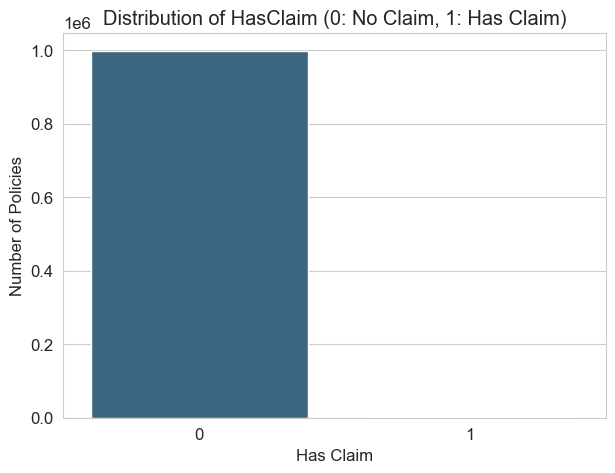


TotalClaims (Claim Severity) Distribution (for policies with claims):
  Column dtype: float64
count      2788.000000
mean      23273.387063
std       38719.512597
min         139.043860
25%        1680.728070
50%        6140.350877
75%       30480.991228
max      393092.105263
Name: TotalClaims, dtype: float64


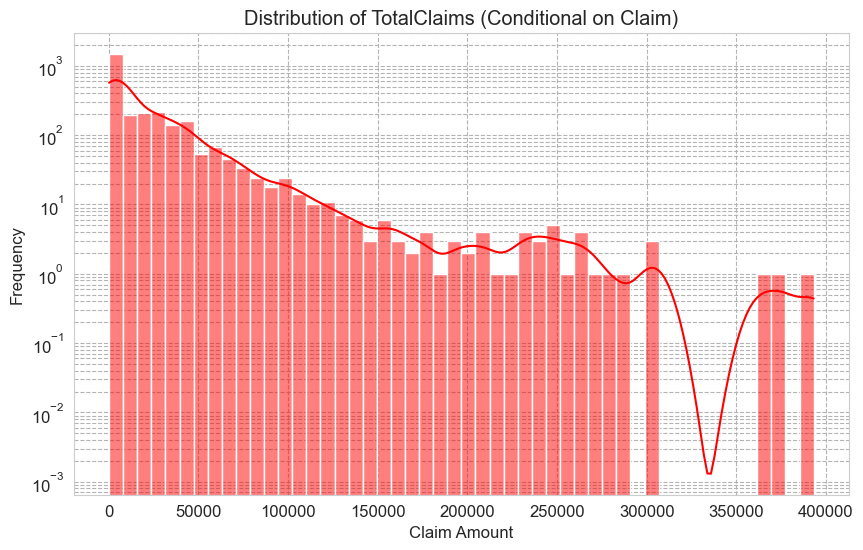


Margin Distribution:
  Column dtype: float64
count    1.000098e+06
mean     6.082549e+01
std      1.887334e+02
min      0.000000e+00
25%      0.000000e+00
50%      2.157687e+00
75%      2.192982e+01
max      6.528260e+04
Name: Margin, dtype: float64


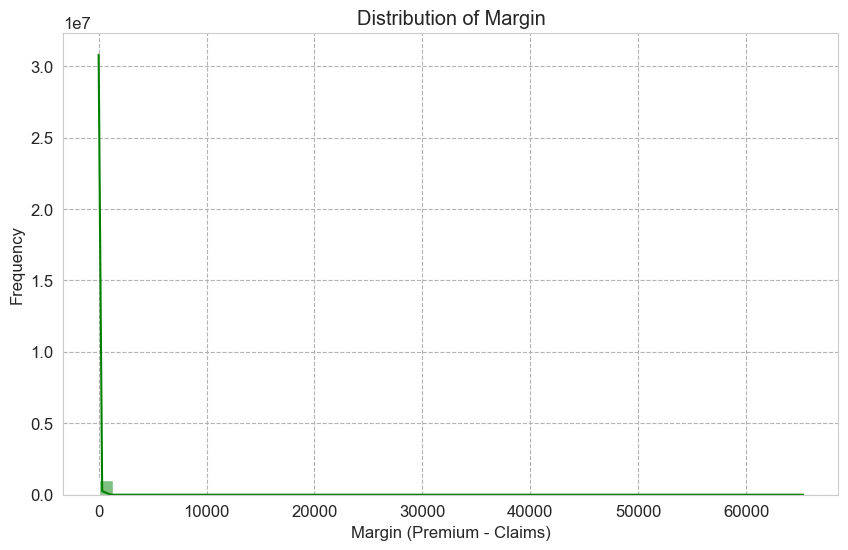

In [19]:
# 6.1. Claim Frequency (HasClaim)
if HAS_CLAIM_COL in df_final_eda.columns:
    print(f"\n{HAS_CLAIM_COL} (Claim Frequency) Distribution:")
    print(f"  Column dtype: {df_final_eda[HAS_CLAIM_COL].dtype}") # Diagnostic print
    claim_counts = df_final_eda[HAS_CLAIM_COL].value_counts(normalize=False)
    claim_percentages = df_final_eda[HAS_CLAIM_COL].value_counts(normalize=True) * 100
    claim_dist = pd.DataFrame({'Count': claim_counts, 'Percentage (%)': claim_percentages})
    display(claim_dist)

    plt.figure(figsize=(7, 5))
    sns.countplot(x=HAS_CLAIM_COL, data=df_final_eda, palette='viridis')
    plt.title(f'Distribution of {HAS_CLAIM_COL} (0: No Claim, 1: Has Claim)')
    plt.xlabel('Has Claim')
    plt.ylabel('Number of Policies')
    plt.show()
else:
    print(f"'{HAS_CLAIM_COL}' column not found for target analysis.")

# 6.2. Claim Severity (TotalClaims conditional on HasClaim > 0)
if TOTAL_CLAIMS_COL in df_final_eda.columns and HAS_CLAIM_COL in df_final_eda.columns:
    print(f"\n{TOTAL_CLAIMS_COL} (Claim Severity) Distribution (for policies with claims):")
    print(f"  Column dtype: {df_final_eda[TOTAL_CLAIMS_COL].dtype}") # Diagnostic print
    claims_only_df = df_final_eda[df_final_eda[HAS_CLAIM_COL] == 1].copy()
    if not claims_only_df.empty:
        print(claims_only_df[TOTAL_CLAIMS_COL].describe())
        plt.figure(figsize=(10, 6))
        sns.histplot(claims_only_df[TOTAL_CLAIMS_COL], bins=50, kde=True, color='red')
        plt.title(f'Distribution of {TOTAL_CLAIMS_COL} (Conditional on Claim)')
        plt.xlabel('Claim Amount')
        plt.ylabel('Frequency')
        plt.yscale('log') # Log scale often useful for skewed financial data
        plt.grid(True, which="both", ls="--", c='0.7') # Corrected: Removed backslashes from which and ls
        plt.show()
    else:
        print("No policies with claims found for Claim Severity analysis.")
else:
    print(f"'{TOTAL_CLAIMS_COL}' or '{HAS_CLAIM_COL}' columns not found for Claim Severity analysis.")

# 6.3. Margin Distribution
if MARGIN_COL in df_final_eda.columns:
    print(f"\n{MARGIN_COL} Distribution:")
    print(f"  Column dtype: {df_final_eda[MARGIN_COL].dtype}") # Diagnostic print
    print(df_final_eda[MARGIN_COL].describe())
    plt.figure(figsize=(10, 6))
    sns.histplot(df_final_eda[MARGIN_COL], bins=50, kde=True, color='green')
    plt.title(f'Distribution of {MARGIN_COL}')
    plt.xlabel('Margin (Premium - Claims)')
    plt.ylabel('Frequency')
    plt.grid(True, which="both", ls="--", c='0.7') # Corrected: Removed backslashes from which and ls
    plt.show()
else:
    print(f"'{MARGIN_COL}' column not found for Margin analysis.")

# 7. Feature Distributions (Sampled Visualizations)


7.1. Numerical Feature Distributions:


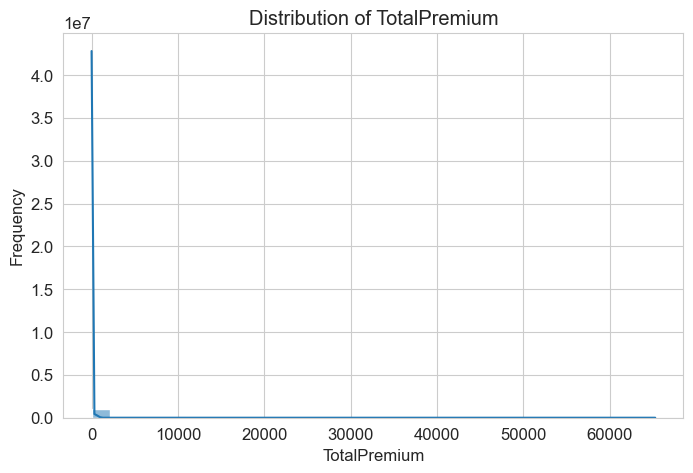

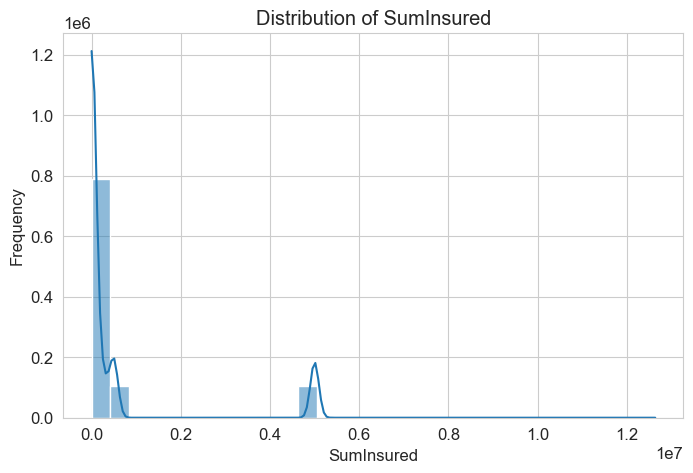

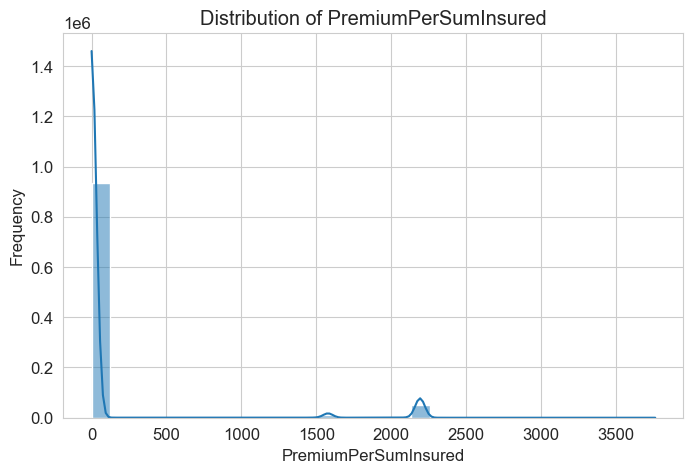

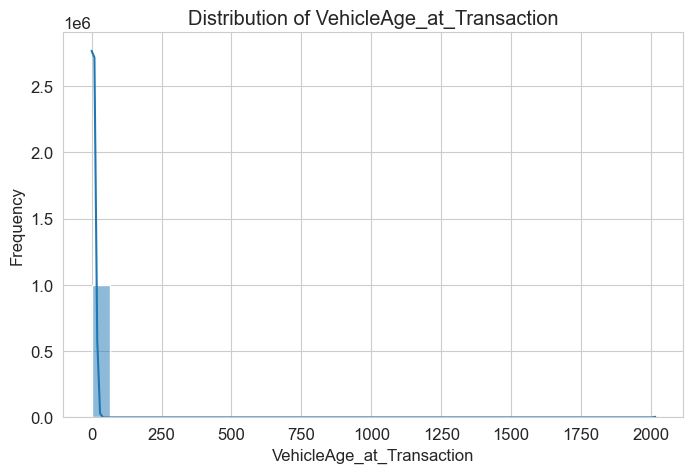


7.2. Categorical Feature Distributions:


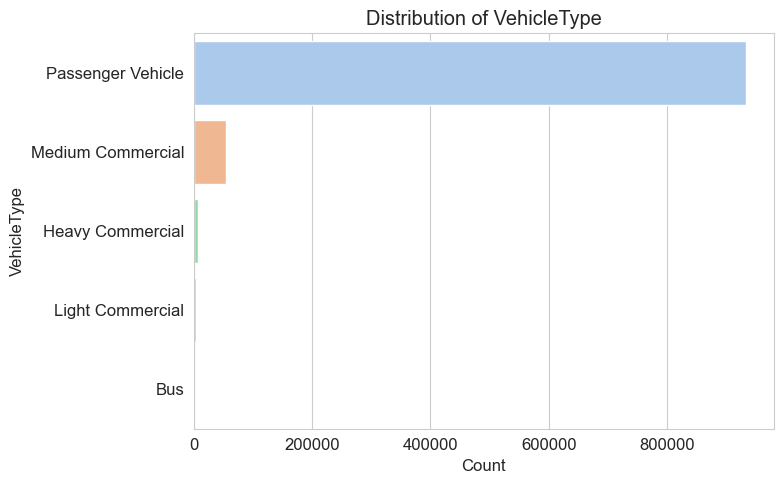

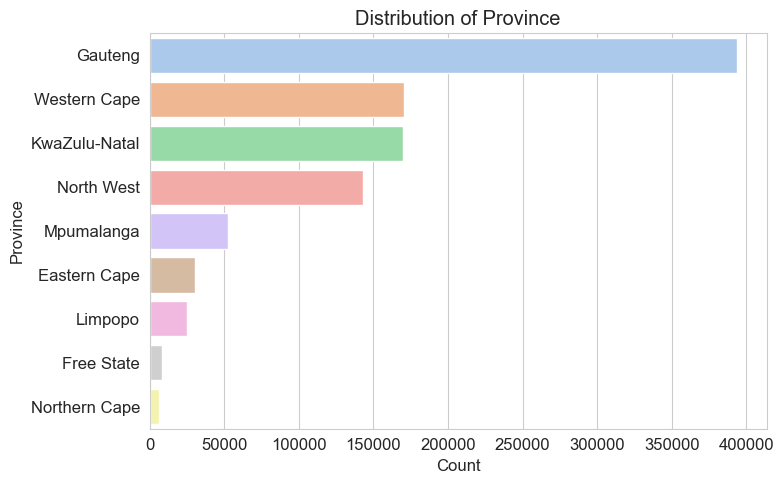

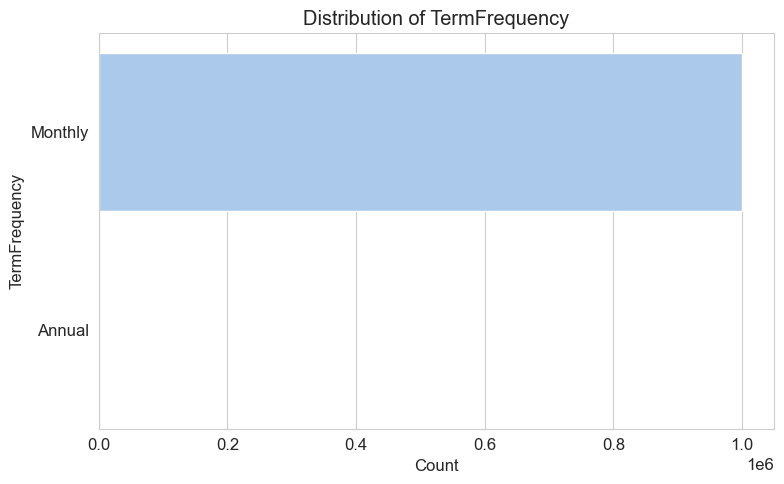

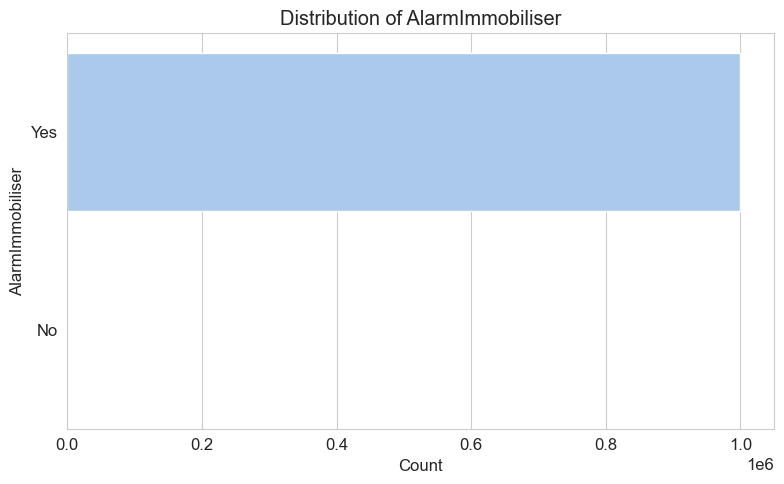

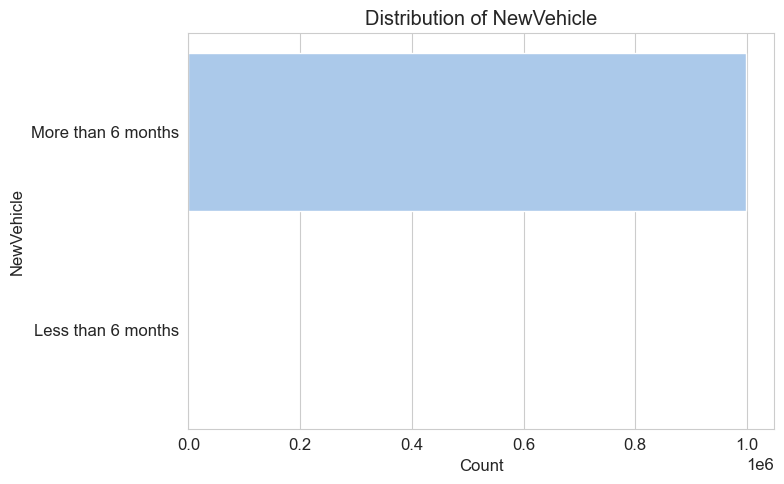

In [20]:
print("\n7.1. Numerical Feature Distributions:")
num_cols_to_plot = [col for col in ['TotalPremium', 'SumInsured', 'Age', 'VehicleAge', 'PremiumPerSumInsured', 'VehicleAge_at_Transaction'] if col in df_final_eda.columns]
for col in num_cols_to_plot:
    if not df_final_eda[col].empty and pd.api.types.is_numeric_dtype(df_final_eda[col]):
        plt.figure(figsize=(8, 5))
        sns.histplot(df_final_eda[col].dropna(), kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
    else:
        print(f"Warning: '{col}' is not suitable for numerical distribution plot or not found.")

print("\n7.2. Categorical Feature Distributions:")
cat_cols_to_plot = [col for col in ['PolicyType', DRIVER_GENDER_COL, 'VehicleType', PROVINCE_COL, 'TermFrequency', 'AlarmImmobiliser', 'NewVehicle'] if col in df_final_eda.columns]
for col in cat_cols_to_plot:
    if not df_final_eda[col].empty and (df_final_eda[col].dtype == 'object' or pd.api.types.is_string_dtype(df_final_eda[col])):
        plt.figure(figsize=(8, 5))
        sns.countplot(y=col, data=df_final_eda, order=df_final_eda[col].value_counts().index, palette='pastel')
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: '{col}' is not suitable for categorical distribution plot or not found.")

# 8. Correlation Analysis


8.1. Correlation Matrix of Numerical Features:


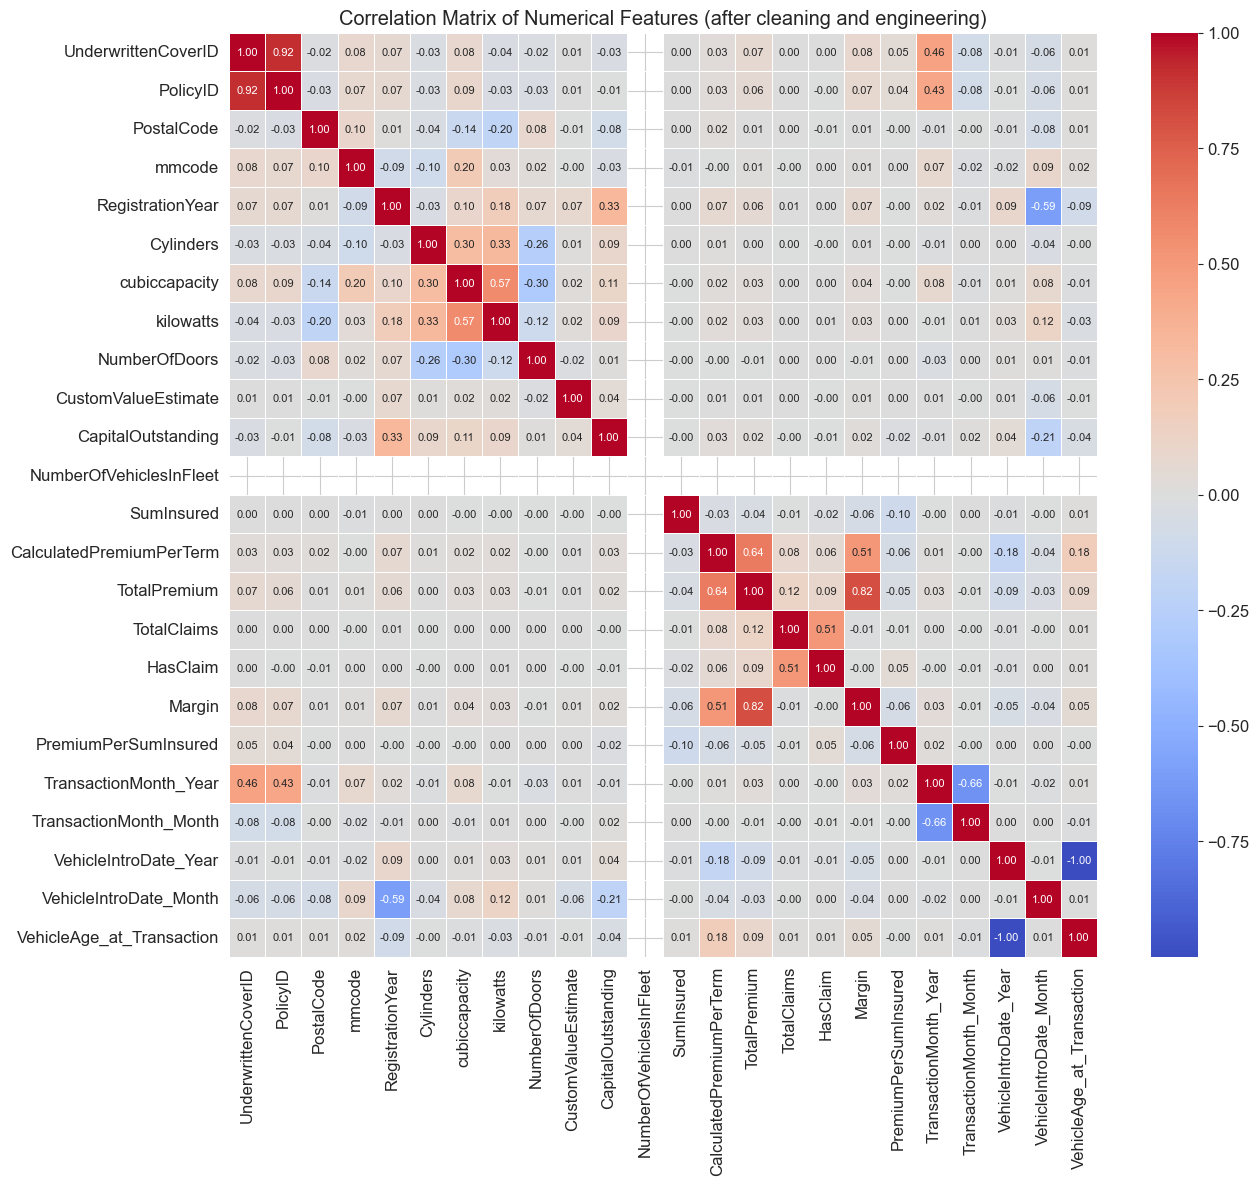


8.2. Correlation with Target Variables:

Correlation with 'HasClaim':


TotalClaims                  0.514714
TotalPremium                 0.090476
CalculatedPremiumPerTerm     0.056612
PremiumPerSumInsured         0.046547
VehicleAge_at_Transaction    0.008723
kilowatts                    0.006265
VehicleIntroDate_Month       0.003042
mmcode                       0.002850
cubiccapacity                0.002233
RegistrationYear             0.001795
NumberOfDoors                0.000744
UnderwrittenCoverID          0.000288
PolicyID                    -0.000304
Cylinders                   -0.000320
CustomValueEstimate         -0.000344
TransactionMonth_Year       -0.001039
Margin                      -0.002889
CapitalOutstanding          -0.005757
TransactionMonth_Month      -0.006931
PostalCode                  -0.006992
VehicleIntroDate_Year       -0.008733
SumInsured                  -0.016224
NumberOfVehiclesInFleet           NaN
Name: HasClaim, dtype: float64

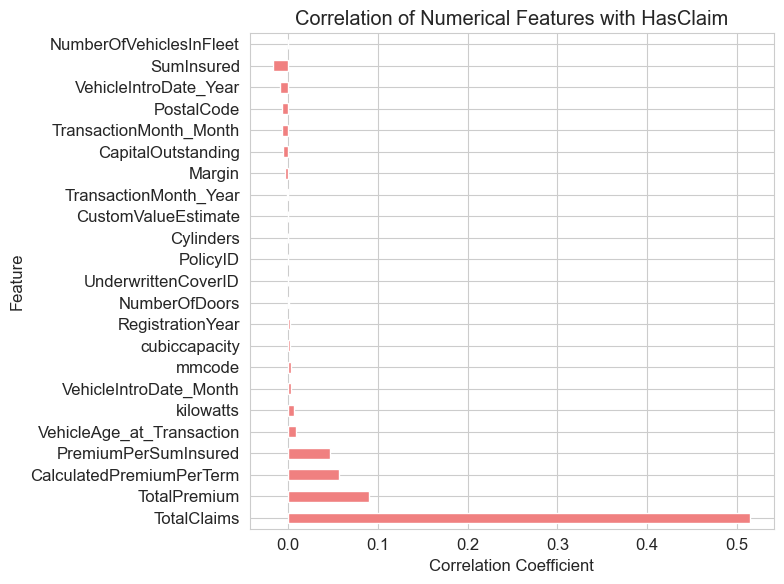


Correlation with 'TotalClaims' (Conditional on Claim):


SumInsured                   0.187740
CalculatedPremiumPerTerm     0.135474
TotalPremium                 0.133237
RegistrationYear             0.104400
PostalCode                   0.095673
CustomValueEstimate          0.089258
PolicyID                     0.076037
UnderwrittenCoverID          0.070505
CapitalOutstanding           0.068096
VehicleAge_at_Transaction    0.032499
NumberOfDoors                0.030189
TransactionMonth_Month       0.019914
TransactionMonth_Year        0.017494
cubiccapacity                0.004887
Cylinders                    0.004243
kilowatts                    0.000348
Margin                      -0.019421
VehicleIntroDate_Year       -0.032441
mmcode                      -0.046420
VehicleIntroDate_Month      -0.063900
PremiumPerSumInsured        -0.348946
NumberOfVehiclesInFleet           NaN
Name: TotalClaims, dtype: float64

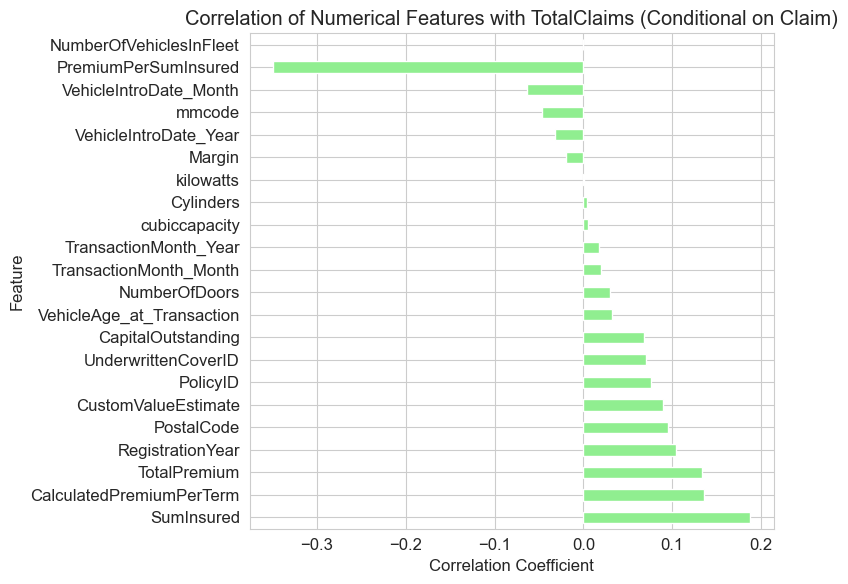


Correlation with 'Margin':


TotalPremium                 0.820089
CalculatedPremiumPerTerm     0.510444
UnderwrittenCoverID          0.078426
PolicyID                     0.071938
RegistrationYear             0.069174
VehicleAge_at_Transaction    0.050692
cubiccapacity                0.036098
TransactionMonth_Year        0.032996
kilowatts                    0.029705
CapitalOutstanding           0.020538
mmcode                       0.010644
CustomValueEstimate          0.009126
PostalCode                   0.006291
Cylinders                    0.005611
TransactionMonth_Month      -0.006160
NumberOfDoors               -0.006811
VehicleIntroDate_Month      -0.037507
VehicleIntroDate_Year       -0.050393
PremiumPerSumInsured        -0.055654
SumInsured                  -0.060226
NumberOfVehiclesInFleet           NaN
Name: Margin, dtype: float64

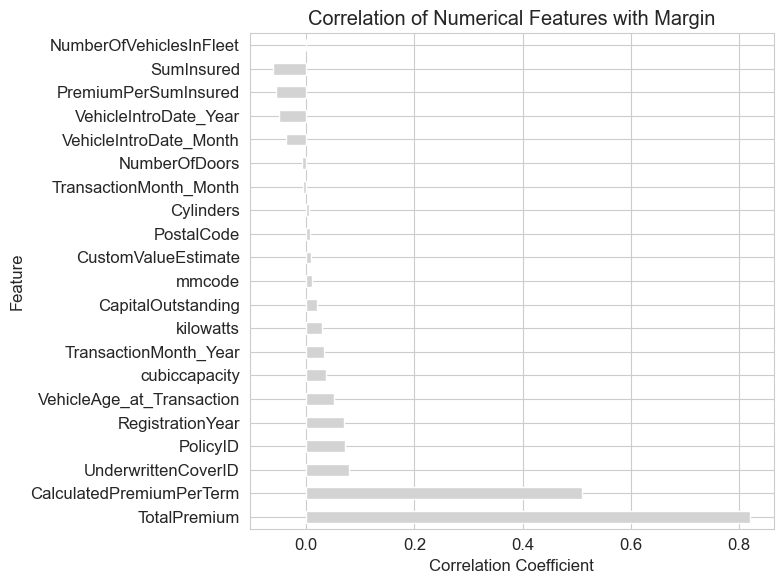

In [21]:
print("\n8.1. Correlation Matrix of Numerical Features:")
# Select only numerical columns for correlation calculation
numeric_df_for_corr = df_final_eda.select_dtypes(include=np.number)
if not numeric_df_for_corr.empty:
    plt.figure(figsize=(14, 12))
    sns.heatmap(numeric_df_for_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
    plt.title('Correlation Matrix of Numerical Features (after cleaning and engineering)')
    plt.show()
else:
    print("No numerical columns found for correlation matrix after processing.")

print("\n8.2. Correlation with Target Variables:")
if HAS_CLAIM_COL in df_final_eda.columns and not df_final_eda[HAS_CLAIM_COL].empty:
    # Correlation of numerical features with 'HasClaim' (point-biserial correlation)
    # For a binary target, correlation is equivalent to point-biserial correlation.
    # We'll use the .corr() method which computes Pearson correlation by default, which is appropriate.
    numeric_features_for_target_corr = [col for col in numeric_df_for_corr.columns if col != HAS_CLAIM_COL]
    if numeric_features_for_target_corr:
        corr_with_has_claim = df_final_eda[numeric_features_for_target_corr + [HAS_CLAIM_COL]].corr().loc[:, HAS_CLAIM_COL].drop(HAS_CLAIM_COL).sort_values(ascending=False)
        print(f"\nCorrelation with '{HAS_CLAIM_COL}':")
        display(corr_with_has_claim)
        
        plt.figure(figsize=(8, 6))
        corr_with_has_claim.plot(kind='barh', color='lightcoral')
        plt.title(f'Correlation of Numerical Features with {HAS_CLAIM_COL}')
        plt.xlabel('Correlation Coefficient')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No numerical features available for correlation with {HAS_CLAIM_COL}.")
else:
    print(f"'{HAS_CLAIM_COL}' column not found for correlation analysis.")

if TOTAL_CLAIMS_COL in df_final_eda.columns and HAS_CLAIM_COL in df_final_eda.columns:
    claims_only_numeric_df = df_final_eda[df_final_eda[HAS_CLAIM_COL] == 1].select_dtypes(include=np.number)
    if not claims_only_numeric_df.empty and TOTAL_CLAIMS_COL in claims_only_numeric_df.columns:
        numeric_features_for_severity_corr = [col for col in claims_only_numeric_df.columns if col != TOTAL_CLAIMS_COL and col != HAS_CLAIM_COL]
        if numeric_features_for_severity_corr:
            corr_with_severity = claims_only_numeric_df[numeric_features_for_severity_corr + [TOTAL_CLAIMS_COL]].corr().loc[:, TOTAL_CLAIMS_COL].drop(TOTAL_CLAIMS_COL).sort_values(ascending=False)
            print(f"\nCorrelation with '{TOTAL_CLAIMS_COL}' (Conditional on Claim):")
            display(corr_with_severity)
            
            plt.figure(figsize=(8, 6))
            corr_with_severity.plot(kind='barh', color='lightgreen')
            plt.title(f'Correlation of Numerical Features with {TOTAL_CLAIMS_COL} (Conditional on Claim)')
            plt.xlabel('Correlation Coefficient')
            plt.ylabel('Feature')
            plt.tight_layout()
            plt.show()
        else:
            print(f"No numerical features available for correlation with {TOTAL_CLAIMS_COL} (conditional).")
    else:
        print(f"No numerical columns or no claims found for {TOTAL_CLAIMS_COL} correlation analysis.")

if MARGIN_COL in df_final_eda.columns and not df_final_eda[MARGIN_COL].empty:
    numeric_features_for_margin_corr = [col for col in numeric_df_for_corr.columns if col != MARGIN_COL and col != HAS_CLAIM_COL and col != TOTAL_CLAIMS_COL]
    if numeric_features_for_margin_corr:
        corr_with_margin = df_final_eda[numeric_features_for_margin_corr + [MARGIN_COL]].corr().loc[:, MARGIN_COL].drop(MARGIN_COL).sort_values(ascending=False)
        print(f"\nCorrelation with '{MARGIN_COL}':")
        display(corr_with_margin)
        
        plt.figure(figsize=(8, 6))
        corr_with_margin.plot(kind='barh', color='lightgray')
        plt.title(f'Correlation of Numerical Features with {MARGIN_COL}')
        plt.xlabel('Correlation Coefficient')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No numerical features available for correlation with {MARGIN_COL}.")
else:
    print(f"'{MARGIN_COL}' column not found for correlation analysis.")

# 9. Conclusion and Next Steps

This EDA has provided insights into the data's quality, distributions, and initial 
relationships between features and targets. Key observations include:

Data Quality: Our preprocessing steps (delimiter correction, numeric coercion, 
    missing value imputation) have significantly improved data quality, though some 
    columns still required careful handling.

Class Imbalance: The HasClaim target variable shows a significant class 
    imbalance, which will need to be addressed during classification model training 
    (e.g., via class_weight or resampling).

Skewed Distributions: Financial columns (TotalPremium, TotalClaims, SumInsured, Margin) 
    exhibit heavily skewed distributions, which is typical for such data. This may influence 
    the choice of regression models or necessitate transformations.

Feature Relationships: Initial correlations provide hints about which features might be 
    strong predictors for claim probability, severity, and margin. Categorical features 
    have diverse distributions, indicating their potential importance.

Next Steps:

Proceed to 02_hypothesis_testing.ipynb to statistically validate key hypotheses about risk drivers.
Proceed to 03_model_development.ipynb to build and evaluate predictive models for claim 
probability and severity, leveraging the insights from EDA and the refined data preparation pipeline.